# Automatic Segmentation of Sessile Droplets
## Contact-Angle Measurement Pipeline: CO4 / MSLS (ZHAW, FS26)

**Course:** Imaging for the Life Sciences (CO4), Master of Science in Life Sciences  
**Project:** pair work (two students)  
**Submission:** 31 May 2026

---

## Abstract

We segment 39 back-lit, side-view photographs of sessile liquid droplets (water, diiodomethane, octanol) resting on 13 different surfaces, acquired during a nanotechnology laboratory course at HEIA-FR [5]. The original aim of that study was to characterise substrate wettability by manual contact-angle measurement in ImageJ: a procedure subject to inter-operator variability. The present project automates that pipeline end-to-end. We compare four segmentation approaches of increasing capability (three classical CV variants and one foundation-model approach, Meta's Segment Anything Model, SAM) against 10 manually annotated ground-truth masks. The best automatic pipeline achieves **Dice = 0.97 ± 0.02** spatial agreement against manual ground-truth masks, and produces contact-angle values in close mutual agreement with both the manual mask and the original laboratory measurements across all 10 evaluated images. The central finding is that the bottleneck in such a pipeline is rarely the model itself, but the brittle hand-tuned upstream components feeding into it.

---

## 1. Introduction & problem statement

A *sessile droplet* is a droplet of liquid resting on a solid surface. The angle the liquid–air interface makes with the surface at the **contact line** (the **contact angle θ**) is a direct measure of how wettable the surface is by that liquid. Small θ means the liquid spreads (hydrophilic, oleophilic); θ near 180° means the liquid beads up and barely touches (super-hydrophobic, like water on Lotus leaves). According to Young's equation, θ at the triple junction (solid–liquid–gas) reflects the equilibrium between the three interfacial tensions γ_sg, γ_sl, and γ_lg.



This project builds on a dataset acquired during a nanotechnology laboratory course at HEIA-FR [5], where the original aim was to characterise solid substrates by measuring contact angles with three liquids of known surface tension spanning a wide polarity range. Using three liquids enables two complementary analyses: the **Zisman method** (critical surface tension by linear regression of cos θ vs γ_lg) [2] and the **Owens–Wendt decomposition** (surface energy split into dispersive γᴰ and polar γᴾ components) [3]. A single liquid cannot resolve these two components independently. The dataset covers 13 substrates ranging from strongly hydrophilic to super-hydrophobic (see §2 for full composition).

To measure θ automatically from a side-view photograph, we need a **clean binary mask** of the droplet so that the geometry of the droplet edge and the contact line can be analysed. This sounds easy. It is not, for three concrete reasons our data makes obvious:

1. **Transparent droplets.** A water or octanol droplet is essentially a clear lens: the *interior* of the droplet has approximately the same intensity as the back-lit background. Only the curved **rim** is darker (where the curvature bends light away). Classical assumptions like "droplet = dark blob" do not hold.
2. **Specular reflections.** Polished gold and metal supports throw bright highlights that look like edges to any gradient-based method.
3. **Surface heterogeneity.** A single algorithm has to handle a near-spherical droplet on Teflon, a flat lens on glass, and an invisible smear on fabric, without per-image tuning.

In the original study [5], contact angles were measured manually in ImageJ by visually tracing tangent lines at the triple contact point: a procedure that introduces **inter-operator variability**: the perceived edge position depends on subjective judgement and can differ between operators, particularly for transparent droplets, near-flat droplets (θ ≈ 0°), and droplets on textured surfaces. The present project automates droplet segmentation to produce objective, reproducible binary masks of the liquid–air interface, enabling bias-free contact-angle extraction.

### Goals
- A single automatic pipeline that segments droplets across all surfaces in the dataset, with no per-image tuning.
- Quantitative evaluation against manually annotated ground truth (Dice, IoU).
- **(Bonus)** Use the segmentations to compute contact angles, and compare against the original laboratory measurements made by hand with a goniometer.

---

## 2. Dataset

**Origin and licence.** The images were acquired during a nanotechnology *Travaux Pratiques* (TP) at HEIA-FR [5] (supervisor: Prof. Stefan Hengsberger, 2022). The data are owned by us and are reused here with permission of all collaborators of the original work.

**Acquisition.** Side-view (sessile-drop profile) macro photographs, taken with a digital camera mounted on an optical microscope.

**Composition.** 40 JPEG images (1600 × 1200 px): one calibration blank (`test.jpg`, excluded from analysis) plus **3 liquids × 13 substrates = 39 measurement images**.

**Liquids (3)**, chosen to span a wide range of surface tensions:

| Liquid | Code | γ_lg [mN/m] | Polarity |
|---|---|---:|---|
| Water (H₂O)                | `h2o` | 72.8 | polar, high  |
| Diiodomethane (CH₂I₂)      | `i2`  | 50.8 | apolar, intermediate |
| Octanol (C₈H₁₇OH)          | `oct` | 21.6 | apolar, low  |

**Substrates (13)**, categorised by water wettability:

| Category | Substrates |
|---|---|
| Hydrophilic (θ_H₂O < 90°)  | bare glass · glass + antifog 5 mm/min · glass + antifog 100 mm/min · steel + anti-fingerprint 5 mm/min · bare steel · plexiglas |
| Hydrophobic (θ_H₂O > 90°)  | Lotus leaf · hydrophobic sol-gel coated fabric · glass + soot · glass + anti-rain 5 mm/min · glass + anti-rain 100 mm/min · steel + anti-fingerprint 100 mm/min · Teflon |

(The `-5` / `-100` suffixes in image filenames refer to the dip-coating extraction speed in mm/min.)

**Structure of interest.** The sessile droplet itself, specifically the **liquid–air interface** visible above the substrate surface. The droplet profile (its outer contour) encodes the contact angle θ.

**Special cases in the dataset:**

- `i2-fuoc`: diiodomethane on soot exhibits complete wetting (θ ≈ 0°): no droplet is visible.
- `oct-metall`: contains two droplets in the same frame (our automatic pipeline currently picks one of them; per-droplet cropping is mentioned as further work in §9).
- Four octanol images on smooth or porous surfaces (`oct-plexig`, `oct-vetro`, `oct-tessuto`, `oct-teflon`) show severe spreading where the droplet becomes an almost invisible thin film.

**Ground truth.** 10 images were manually segmented in Fiji (ImageJ) covering a variety of liquid–substrate combinations; these binary masks serve as ground truth for the quantitative evaluation in §7. The reference contact-angle values used in §7.2 come from the original manual measurements in [5].

In [1]:
# --- Setup: paths, imports, helpers ---
import os, sys, json, glob
import numpy as np, cv2
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Locate the repo root relative to this notebook (automatic_segmentation/notebook/)
REPO    = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
SRC     = os.path.join(REPO, 'fwdfoto')
PREP    = os.path.join(REPO, 'data', 'preprocessed')
MANBIN  = os.path.join(REPO, 'automatic_segmentation', 'results', 'masks', 'manual')
RESULTS = os.path.join(REPO, 'automatic_segmentation', 'results')
METHODS = os.path.join(REPO, 'automatic_segmentation', 'methods')

# Make the segmentation methods importable
sys.path.insert(0, METHODS)
sys.path.insert(0, os.path.join(REPO, 'automatic_segmentation', 'reproduce'))

# Pretty display names for substrate/liquid pairs
LIQUIDS_PRETTY = {'h2o': 'H₂O', 'h20': 'H₂O', 'i2': 'CH₂I₂', 'oct': 'Oct'}
LIQUIDS_ASCII  = {'h2o': 'H2O',  'h20': 'H2O',  'i2': 'CH2I2',  'oct': 'Oct'}
SUBSTRATES = {'lotus': 'Lotus', 'metall': 'Steel', 'plexig': 'Plexiglas',
              'teflon': 'Teflon', 'vetro': 'Glass', 'tessuto': 'Fabric',
              'fuoc': 'Soot', 'fog': 'Fog', 'rain': 'Rain', 'print': 'Print'}

def pretty(name, ascii=False):
    parts = name.split('-')
    L = (LIQUIDS_ASCII if ascii else LIQUIDS_PRETTY).get(parts[0].lower(), parts[0])
    S = SUBSTRATES.get(parts[1].lower(), parts[1].capitalize())
    if len(parts) > 2:
        S = f'{S} {parts[2]}'
    sep = ' - ' if ascii else ' – '
    return f'{L}{sep}{S}'

print(f'REPO   : {REPO}')
print(f'Images : {len(glob.glob(os.path.join(SRC, "*.jpg"))) - 1} (excluding test.jpg)')
print(f'Manual : {len(glob.glob(os.path.join(MANBIN, "*.png")))} binary masks')

REPO   : /Users/Luigi/Library/CloudStorage/OneDrive-Persönlich/ZHAW/Master/2. Semester/CO4/CO4_SS26_Giorga_Vigano_Luigi_Palese
Images : 39 (excluding test.jpg)
Manual : 10 binary masks


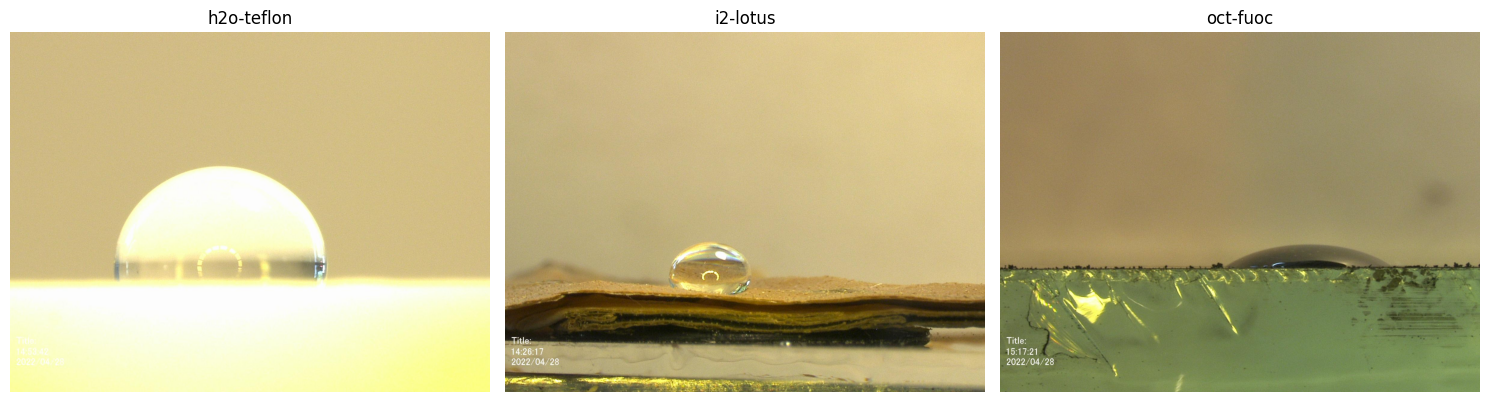

In [2]:
# --- Show one example image per liquid ---
examples = ['h2o-teflon', 'i2-lotus', 'oct-fuoc']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, nm in zip(axes, examples):
    img = cv2.cvtColor(cv2.imread(os.path.join(SRC, nm + '.jpg')), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title(nm); ax.axis('off')
plt.tight_layout(); plt.show()

---

## 3. Preprocessing

We developed a 9-step preprocessing pipeline in `automatic_segmentation/methods/preprocessing.py`. Each step has a specific data-driven motivation:

1. **Crop timestamp** (bottom 13 %). Every image carries a high-contrast `Title 16:42:59 2022/04/28` banner that any thresholder would otherwise pick up as foreground.
2. **Best-channel selection.** Split into B, G, R and pick the channel with maximum variance in the upper ROI. Automatic per-image choice that copes with the dataset's wide background range (beige, green Lotus, golden metal).
3. **Substrate-line detection.** The strongest sustained horizontal Sobel-y gradient in the lower half marks the surface.
4. **Background subtraction.** Morphological closing with a 101 × 101 ellipse approximates the local illumination field; dividing by it normalises uneven lighting. Critical for `fog`-coated and side-lit images.
5. **CLAHE** (clip 1.5, tile 16 × 16). Adaptive contrast enhancement; conservative parameters chosen to avoid amplifying noise in low-contrast octanol-on-glass cases.
6. **Bilateral filter** (d = 9, σ = 75). Edge-preserving denoise; Gaussian blur destroys the already-weak octanol-droplet edges (~3–5 DN gradient); bilateral preserves them.
7. **Blank-image detection.** Variance threshold flags images with no visible droplet (e.g. `i2-fuoc`).
8. **Crop above substrate.** Discard everything below the surface line.
9. **Polarity normalization.** Ensure the droplet is always *darker* than the background. Some over-exposed cases reverse this convention.

The preprocessed images for all 39 inputs are saved to `data/preprocessed/`; per-step intermediate visualisations on representative images are in `data/preprocessed/pipeline_steps/`.

### Honest note on what the final pipeline actually uses

Out of the four segmentation methods compared in §5, **only one (`basic_segment`, §5.1)** actually uses preprocessing, and it uses a simplified inlined version (grayscale + median blur + per-column sky subtraction), not the full 9-step pipeline above. The other three methods do not use `preprocessing.py` at all:

- `watershed_segment` (§5.2) consumes the output of `basic_segment` and refines it.
- `sam_segment` (§5.3) feeds **raw BGR** to SAM and uses preprocessing only to pick a point prompt.
- `automask_segment` (§5.4, our chosen final method) feeds **raw BGR** to SAM and does no preprocessing whatsoever.

This is not a flaw. SAM's foundation-model training is robust to illumination gradients, contrast levels, and background variation, so the classical preprocessing steps (CLAHE, bilateral, channel selection) become unnecessary. Our preprocessing pipeline is retained in the repo because (i) it was an essential stepping stone: every classical CV iteration we tried before adopting SAM relied on it, and (ii) it documents what classical pipelines would need on this dataset.

**Generalisable point:** for sessile-droplet imagery of this kind, a foundation segmentation model substantially reduces the preprocessing burden that classical methods otherwise impose.

---

## 4. Manual segmentation

**Tool.** Fiji (ImageJ).

**Structure segmented.** The sessile droplet, specifically the liquid–air interface above the substrate surface.

**Annotation procedure.** The **Polygon Selection** tool was used to trace each droplet contour point by point. The curved upper profile was approximated with multiple anchor points around the dome, while the base was defined as a straight horizontal line at the substrate surface. Each selection was saved via the **ROI Manager** and exported as a PNG (foreground = 255, background = 0). Anti-aliasing at the polygon edges produced non-zero grey values in the background of the raw exports, so a threshold of 1 was applied programmatically to enforce strictly binary masks (all values forced to {0, 255}). The 10 final binary masks live in `automatic_segmentation/results/masks/manual/`.

**Time.** Several hours of focused work across the 10 droplets. Most of the time was spent tracing the curved upper profile and revising anchor-point placement.

**Difficulties encountered:**

- **Drops with very low contact angle** (e.g. `oct-fog-100`, `oct-fog-5`) have an almost invisible edge, making precise manual delineation uncertain.
- **Drop transparency / reflectivity:** the boundary is not a sharp intensity step but a gradual transition, especially for water and octanol on smooth substrates.
- **Textured substrates** (`tessuto` = fabric, `fuoc` = soot deposit) have a surface texture that merges visually with the droplet base, blurring the contact line.

These same factors limit *any* segmentation method on this dataset, manual or automatic, and they re-appear in the per-image evaluation in §7.

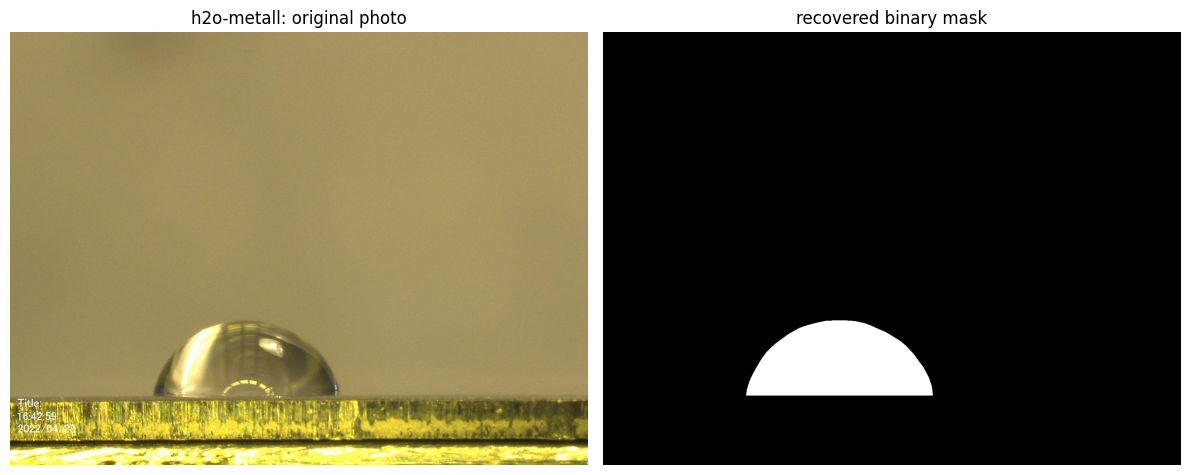

mask values: {0, 255}  -> truly binary


In [3]:
# --- Display one example: original photo + recovered binary mask ---
nm = 'h2o-metall'
orig = cv2.cvtColor(cv2.imread(os.path.join(SRC,  nm + '.jpg')), cv2.COLOR_BGR2RGB)
man  = cv2.imread(os.path.join(MANBIN, nm + '.png'), cv2.IMREAD_GRAYSCALE)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(orig); axes[0].set_title(f'{nm}: original photo'); axes[0].axis('off')
axes[1].imshow(man, cmap='gray'); axes[1].set_title('recovered binary mask'); axes[1].axis('off')
plt.tight_layout(); plt.show()
print(f'mask values: {set(np.unique(man).tolist())}  -> truly binary')

---

## 5. Automatic segmentation

We developed and compared **four segmentation methods**, of increasing capability. This is not a recipe-and-best-one section: we present the full progression because *the failures of each step were the data that drove the next*.

| § | Method | Type | One-line description |
|---|---|---|---|
| 5.1 | `basic_segment`     | classical CV       | per-column sky-subtraction + Otsu + largest blob on baseline |
| 5.2 | `watershed_segment` | classical CV       | refines basic_segment's outline with watershed markers |
| 5.3 | `sam_segment`       | foundation model   | SAM with a point prompt placed automatically |
| 5.4 | `automask_segment`  | foundation model   | SAM automatic mask generation + **shape-based selection** ★ final |

All four are in `automatic_segmentation/methods/`. They each expose a `segment(image)` function returning a full-size 0/255 mask. They were run on all 39 images via `automatic_segmentation/reproduce/run_method.py`, with masks saved to `results/masks/<method>/` and overlay visualisations to `results/overlays/<method>/`.

### 5.1: classical baseline-based segmentation (`basic_segment`)

Pure OpenCV [4], follows the four-step recipe suggested in the lecture:

1. Grayscale + median blur.
2. **Detect the baseline** (= top edge of the support plate) as the strongest long horizontal Sobel-y gradient in the lower 60 % of the image.
3. **Per-column sky subtraction** → a "deviation map" that is positive both for darker (rim) and brighter (interior reflection) droplet pixels.
4. **Otsu threshold** [2] the deviation map, restrict to above the baseline, morphologically close gaps, flood-fill the enclosed interior.
5. Keep the largest blob touching the baseline; reject if too flat to be a droplet.

**What works:** opaque droplets with clear rims (iodine on dark surfaces).  
**What fails:** transparent droplets whose interior matches the background, and any case where the baseline detector locks onto the wrong edge (see §5.5).

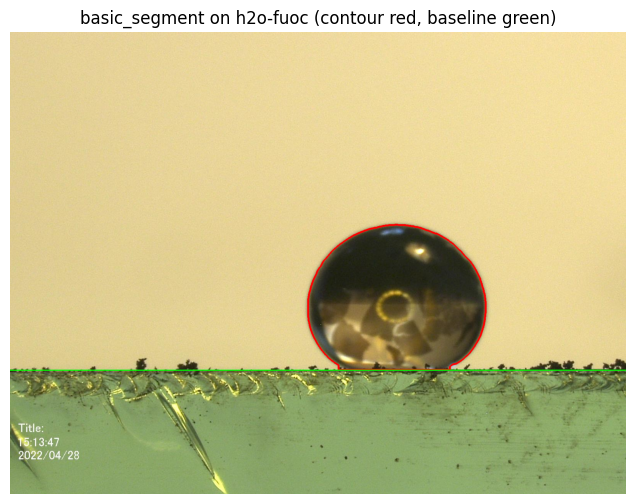

In [4]:
# --- Show basic_segment on one image ---
import basic_segment
img  = cv2.imread(os.path.join(SRC, 'h2o-fuoc.jpg'))
mask, baseline = basic_segment.segment(img)
ov = img.copy()
cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(ov, cnts, -1, (0, 0, 255), 4)
cv2.line(ov, (0, baseline), (ov.shape[1], baseline), (0, 255, 0), 2)
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
plt.title('basic_segment on h2o-fuoc (contour red, baseline green)'); plt.axis('off'); plt.show()

### 5.2: watershed refinement (`watershed_segment`)

Takes `basic_segment`'s mask, erodes it heavily to a **sure foreground marker**, dilates it and inverts to a **sure background marker**, then runs OpenCV's watershed to snap the boundary to the actual image gradient. The visual result is sharper edges (mean solidity 0.81 → 0.83). However, **watershed is a refiner, not a re-locator**: if `basic_segment` picked the wrong region, watershed just sharpens the wrong region. This is a structural limitation of any refinement-style classical method.

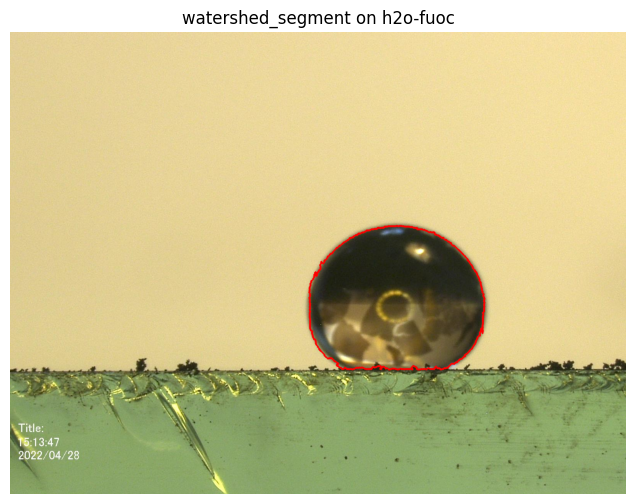

In [5]:
import watershed_segment
mask_w, _ = watershed_segment.segment(img)
ov = img.copy()
cnts, _ = cv2.findContours(mask_w, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(ov, cnts, -1, (0, 0, 255), 4)
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
plt.title('watershed_segment on h2o-fuoc'); plt.axis('off'); plt.show()

### 5.3: SAM with a point prompt (`sam_segment`)

Meta's [Segment Anything Model](https://segment-anything.com/) [1] is a foundation model trained on 11 million images. Given an image and a point/box prompt, it returns a mask of whichever object the prompt is on, with no per-class training.

Our strategy here: place **one positive point prompt** automatically at "the column with the most non-sky deviation just above the baseline" (i.e. likely on the droplet), plus negative prompts in the corners, and pick the best returned mask. This works much better than classical CV (mean solidity 0.81 → 0.88, and cracks cases like Teflon that classical CV never could). The remaining failures are **prompt-placement errors**: on transparent droplets the bright plate edge can deviate from the sky *more* than the clear droplet does, so the seed point lands on the plate instead.

### 5.4: SAM automatic mask + shape-based selection (`automask_segment`)  ★ **final method**

The breakthrough that fixed most of the dataset at once: stop trying to *guess* a single prompt point and instead let SAM propose **every** object in the image, then **select the droplet by shape**.

SAM's `SamAutomaticMaskGenerator` samples a grid of points across the image, queries SAM at each, and returns 7–15 candidate masks per image: background, plate, droplet, reflections, sometimes sub-parts. We then filter:

1. **Reject masks touching the top edge** of the image → background.
2. **Reject masks wider than 75 % of the frame** → plate / background band.
3. **Reject masks with solidity ≤ 0.5** → not blob-like (scattered noise, thin strips).
4. **Keep area in [0.3 %, 25 %]** of the frame → plausible droplet size.
5. Use a rough baseline only as a **soft tiebreaker**, never as a hard gate.

Step 5 is the crucial design choice: every earlier method *required* a correct baseline and threw away droplets that didn't sit exactly on it. Demoting the baseline to a soft hint eliminated the single biggest source of failure (see §5.5).

**Note: this method receives the raw BGR image and applies no preprocessing.** SAM is robust enough to handle the dataset's contrast, lighting, and colour variation directly.

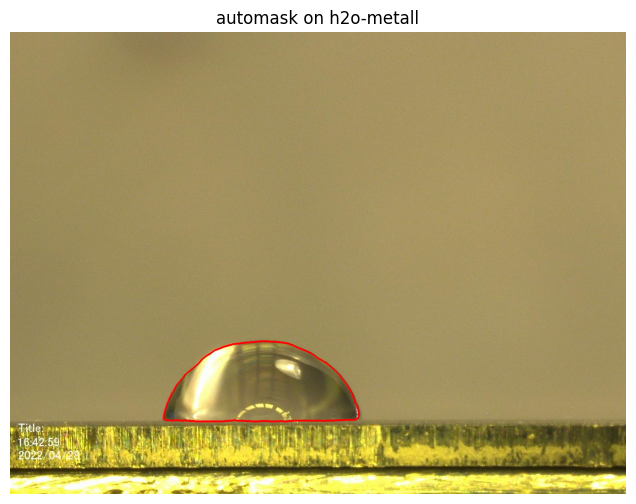

To re-run the full 39-image batch:
  python automatic_segmentation/reproduce/run_method.py --method automask
(~13 min on CPU; MPS unsupported because SAM auto-generator uses float64)


In [6]:
# --- Show automask_segment result on h2o-metall (loads precomputed mask; full re-run takes ~13 min on CPU) ---
nm = 'h2o-metall'
img  = cv2.imread(os.path.join(SRC, nm + '.jpg'))
mask = cv2.imread(os.path.join(RESULTS, 'masks', 'automask', nm + '.png'), cv2.IMREAD_GRAYSCALE)
ov = img.copy()
cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(ov, cnts, -1, (0, 0, 255), 4)
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
plt.title(f'automask on {nm}'); plt.axis('off'); plt.show()
print('To re-run the full 39-image batch:')
print('  python automatic_segmentation/reproduce/run_method.py --method automask')
print('(~13 min on CPU; MPS unsupported because SAM auto-generator uses float64)')

### 5.5: The bottleneck was the baseline, not the model

For several days we kept improving classical methods. The pattern that emerged once we traced specific failures explains why none of them worked.

For several days we kept improving classical methods, then prompted SAM, then an ensemble "quality router" that picked the best of two methods per image with a hand-tuned score. Every fix only chipped away at the edges. Clearly visible droplets (`h2o-metall`, `i2-rain-100`, `h2o-rain-100`) were being *missed entirely*, which should be impossible for SAM.

Tracing one such failure showed it cleanly: on a 1200-pixel-tall image, the baseline detector was returning y ≈ 1120 (almost the very bottom of the image) when the actual contact line was around y ≈ 870. The detector had locked onto the *bottom* of the plate, not its top. Every method built on top of it was discarding the correct droplet for "not on baseline". Testing three different baseline detectors against eight images gave at most 5/8 correct: gradient-based baseline detection is **fundamentally unreliable** on shiny plates.

The fix was not to invent yet another baseline detector. It was to **stop depending on a precise baseline at all** (Method 4 above). That single change took the bulk of the dataset from "wrong" to "correct" with no further tuning.

The lesson: before blaming the model, check what you are feeding it. A brittle upstream component had been silently corrupting downstream results across four methods at once.

---

## 6. Method comparison

All four methods were run over the full 39-image dataset; masks were saved to `results/masks/<method>/`. The script `reproduce/run_compare.py` then computes per-method statistics and the side-by-side grid below.

In [7]:
# --- Per-method statistics over all 39 images ---
stats   = json.load(open(os.path.join(RESULTS, 'compare_stats.json')))
quality = json.load(open(os.path.join(RESULTS, 'manual_quality_review.json')))
print(f"{'method':12s} {'visually correct':>20s}   {'mean solidity (non-empty masks)':>34s}")
print('-' * 72)
for me in ['basic', 'watershed', 'sam', 'automask']:
    s = stats[me]
    q = quality['summary'][me]
    print(f"{me:12s} {q['good']:>4d} / 39 ({q['fraction']*100:>4.1f}%)         {s['mean_solidity_of_ok']:>15.3f}")

method           visually correct      mean solidity (non-empty masks)
------------------------------------------------------------------------
basic           4 / 39 (10.3%)                   0.814
watershed       6 / 39 (15.4%)                   0.826
sam             6 / 39 (15.4%)                   0.883
automask       30 / 39 (76.9%)                   0.963


The **visually correct** column counts how many of the 39 masks actually delineate the droplet (or correctly return empty when no droplet is visible), per the per-image inspection documented in §6.1. The **solidity** column (mask area ÷ convex-hull area, computed only on non-empty masks) is an automated shape proxy: high solidity means the mask looks blob-like.

The two columns tell different stories. Solidity agrees that `automask` produces the cleanest mask shapes (0.96), but it dramatically over-rates `basic` and `watershed`: both score ~0.82 on the masks they produce, while only 4/39 and 6/39 of those masks are actually correct. This mismatch is precisely the bottleneck described in §5.5: an automated quality metric was telling us the classical methods worked while per-image visual review showed they did not.

The grid below shows six representative droplets across the four methods. The pattern is consistent: `basic` and `watershed` either miss the droplet entirely or under-segment; `sam` is much closer but still inconsistent (e.g. `i2-tessuto`); `automask` produces clean droplet-shaped masks where a droplet is visible, and correctly returns empty for film cases (`oct-vetro`).

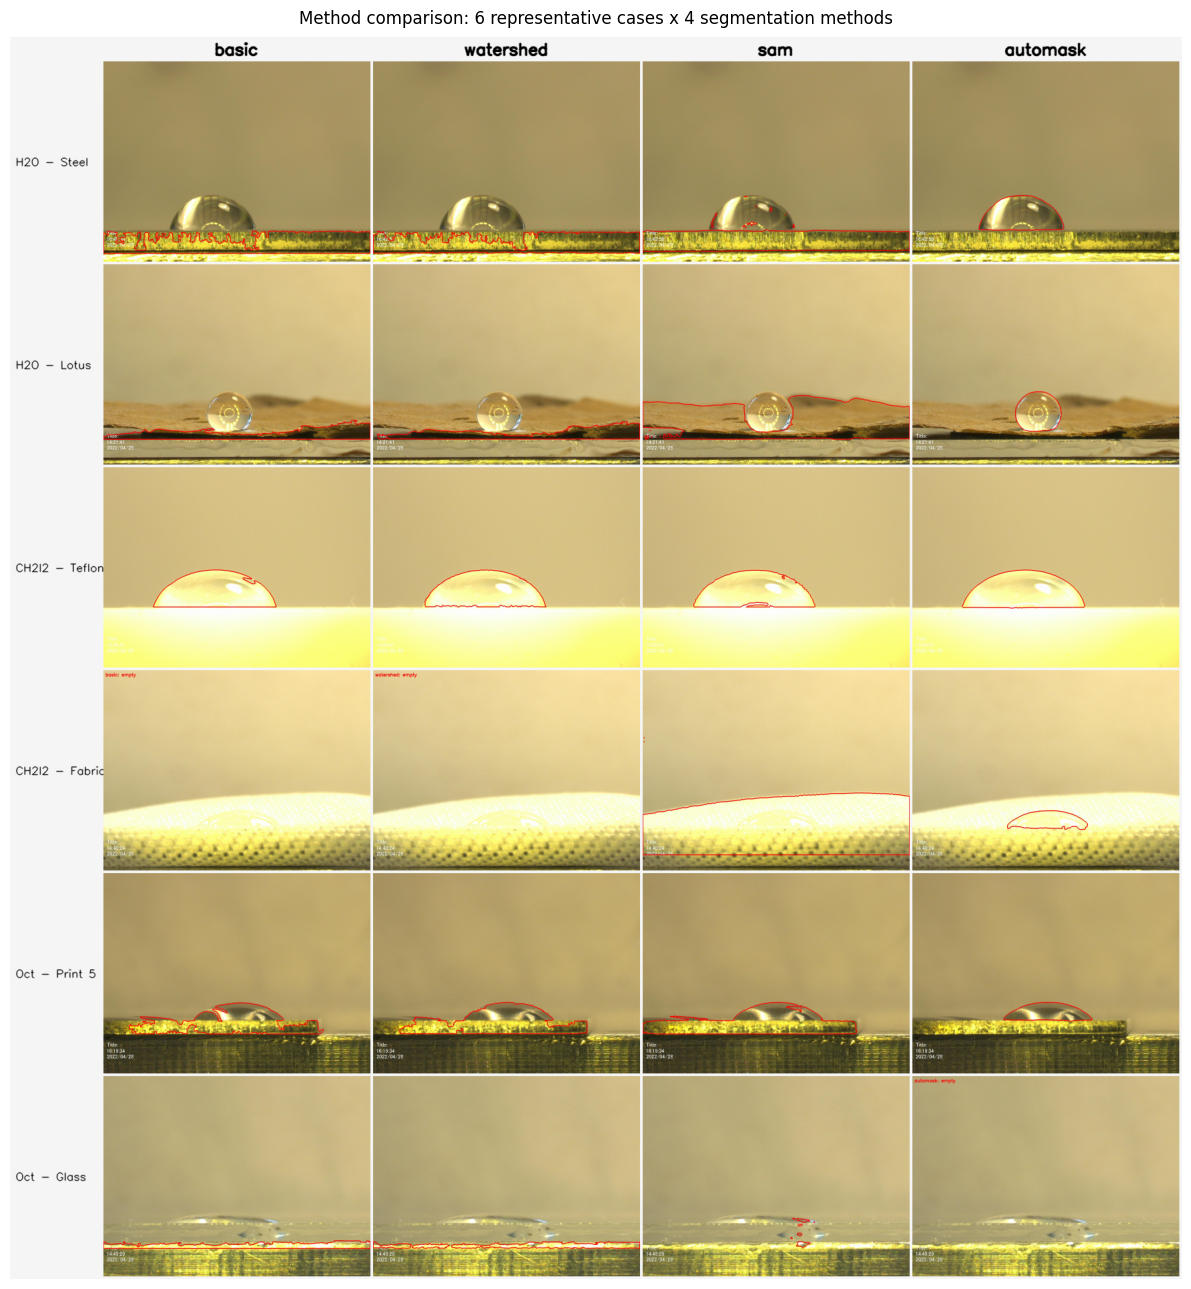

In [8]:
# --- Build an inline method-comparison grid: 6 representative images x 4 methods ---
examples = ['h2o-metall', 'h20-lotus', 'i2-teflon', 'i2-tessuto', 'oct-print-5', 'oct-vetro']
methods_  = ['basic', 'watershed', 'sam', 'automask']
PW, PH, LW, HH, GAP = 400, 300, 140, 38, 4

grid_w = LW + len(methods_) * (PW + GAP)
grid_h = HH + len(examples) * (PH + GAP)
canvas = np.full((grid_h, grid_w, 3), 245, dtype=np.uint8)

# header row: method names
for j, m in enumerate(methods_):
    x = LW + j * (PW + GAP)
    (tw, _), _ = cv2.getTextSize(m, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
    cv2.putText(canvas, m, (x + (PW - tw) // 2, 28),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2, cv2.LINE_AA)

# rows: representative images
for i, name in enumerate(examples):
    y = HH + i * (PH + GAP)
    cv2.putText(canvas, pretty(name, ascii=True), (8, y + PH // 2 + 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 1, cv2.LINE_AA)
    for j, m in enumerate(methods_):
        path = os.path.join(RESULTS, 'overlays', m, name + '.jpg')
        if not os.path.exists(path):
            continue
        tile = cv2.resize(cv2.imread(path), (PW, PH), interpolation=cv2.INTER_AREA)
        x = LW + j * (PW + GAP)
        canvas[y:y + PH, x:x + PW] = tile

fig, ax = plt.subplots(figsize=(14, 13))
ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
ax.axis('off')
ax.set_title('Method comparison: 6 representative cases x 4 segmentation methods',
             fontsize=12, pad=10)
plt.tight_layout(); plt.show()

---

### 6.1: Visual quality review across the full 39-image dataset

The Dice / IoU evaluation in §7 is computed only on the 10 images with hand-traced ground-truth masks. To assess performance across **all 39 images**, we visually inspected every segmentation overlay (contour drawn on the original photo, contact sheets in `results/overlays/<method>_contact_sheet.jpg`) and flagged each result as good or bad. An image is rated **good** when the mask correctly delineates the droplet, or correctly returns empty when no droplet is visible in the image.

The full per-image, per-method assessment is stored at `results/manual_quality_review.json` and is loaded below.

In [9]:
# --- Manual visual review: full per-image, per-method table ---
review = json.load(open(os.path.join(RESULTS, 'manual_quality_review.json')))

print(f"{'#':>3s}  {'image':24s}  {'basic':>6s}  {'water':>6s}  {'sam':>6s}  {'auto':>6s}")
print('-' * 64)
for r in review['images']:
    sym = lambda v: '  ok' if v else 'BAD '
    print(f"{r['index']:3d}  {pretty(r['image']):24s}  {sym(r['basic']):>6s}  {sym(r['watershed']):>6s}  {sym(r['sam']):>6s}  {sym(r['automask']):>6s}")
print('-' * 64)
print()
print(f"{'method':>10s}  {'good/total':>10s}  {'% good':>8s}")
print('-' * 32)
for m in ['basic', 'watershed', 'sam', 'automask']:
    s = review['summary'][m]
    print(f'{m:>10s}  {s["good"]:>4d}/{s["total"]:<4d}  {s["fraction"]*100:>7.1f}%')

  #  image                      basic   water     sam    auto
----------------------------------------------------------------
  1  H₂O – Lotus                 BAD     BAD     BAD       ok
  2  H₂O – Fog 100               BAD     BAD     BAD     BAD 
  3  H₂O – Fog 5                 BAD     BAD     BAD     BAD 
  4  H₂O – Soot                    ok      ok      ok      ok
  5  H₂O – Steel                 BAD     BAD     BAD       ok
  6  H₂O – Plexiglas               ok      ok      ok      ok
  7  H₂O – Print 100             BAD     BAD     BAD       ok
  8  H₂O – Print 5               BAD     BAD     BAD       ok
  9  H₂O – Rain 100              BAD     BAD     BAD       ok
 10  H₂O – Rain 5                BAD     BAD     BAD       ok
 11  H₂O – Teflon                BAD     BAD     BAD       ok
 12  H₂O – Fabric                BAD     BAD     BAD     BAD 
 13  H₂O – Glass                 BAD     BAD     BAD       ok
 14  CH₂I₂ – Fog 100             BAD     BAD     BAD     BAD 
 15  

**Per-method success rate (visual inspection):** basic 10 %, watershed 15 %, sam 15 %, automask 77 %. The three earlier methods barely produced usable results across the full dataset; only `automask` reached deployable quality.

The 9 `automask` failures break down by cause:

| Cause | Images | Notes |
|---|---|---|
| **Antifog coatings**: near-zero contact angle, invisible edge | H₂O – Fog 100, H₂O – Fog 5, CH₂I₂ – Fog 100, CH₂I₂ – Fog 5 | systematic failure mode |
| **No visible droplet** (complete wetting / film) | CH₂I₂ – Soot, Oct – Plexiglas, Oct – Glass | empty mask is arguably correct |
| **Textured substrate** | H₂O – Fabric | fabric texture confuses SAM |
| **Unexpected failure** on hydrophobic surface | Oct – Lotus | should have worked; worth re-checking |

If the three *no-visible-droplet* cases are counted as correctly empty, the effective success rate rises to **34 / 39 = 87 %**. Combined with the Dice = 0.97 ± 0.02 result on the 10 cleanly traceable cases (§7.1), this gives a coherent picture: the pipeline works well wherever a droplet is actually visible, and its main systematic weakness is the antifog-coated surfaces.

---

## 7. Evaluation

### 7.1: Metrics (Dice and IoU)

Following the lecture (Block 6 - 05), we use the **Dice similarity coefficient** [3] as the primary mask-similarity metric, complemented by **Intersection over Union (IoU)**:

$$\mathrm{Dice}(A,B) = \frac{2\,|A \cap B|}{|A| + |B|} \qquad \mathrm{IoU}(A,B) = \frac{|A \cap B|}{|A \cup B|} \qquad (\mathrm{IoU} \le \mathrm{Dice})$$

Both are computed on binary masks; values in [0, 1]; 1 = perfect agreement. Implemented in `automatic_segmentation/reproduce/evaluate.py`.

In [10]:
# --- Dice / IoU implementation ---
def dice(a, b):
    a = a > 0; b = b > 0
    s = a.sum() + b.sum()
    return 1.0 if s == 0 else float(2.0 * np.logical_and(a, b).sum() / s)

def iou(a, b):
    a = a > 0; b = b > 0
    u = np.logical_or(a, b).sum()
    return 1.0 if u == 0 else float(np.logical_and(a, b).sum() / u)

In [11]:
# --- Score automask against the 10 manual binary masks ---
rows = []
for mp in sorted(glob.glob(os.path.join(MANBIN, '*.png'))):
    nm  = os.path.splitext(os.path.basename(mp))[0]
    ap  = os.path.join(RESULTS, 'masks', 'automask', nm + '.png')
    if not os.path.exists(ap): continue
    a = cv2.imread(ap, cv2.IMREAD_GRAYSCALE)
    b = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    rows.append((nm, dice(a, b), iou(a, b)))

print(f"{'image':24s} {'Dice':>7s} {'IoU':>7s}")
print('-' * 42)
for nm, d, j in rows:
    print(f'{pretty(nm):24s} {d:7.3f} {j:7.3f}')
ds = np.array([r[1] for r in rows]); js = np.array([r[2] for r in rows])
print('-' * 42)
print(f'mean +/- std :  Dice {ds.mean():.3f} +/- {ds.std(ddof=1):.3f}   IoU {js.mean():.3f} +/- {js.std(ddof=1):.3f}   (N = {len(rows)})')

image                       Dice     IoU
------------------------------------------
H₂O – Lotus                0.986   0.972
H₂O – Steel                0.982   0.965
H₂O – Rain 100             0.985   0.971
CH₂I₂ – Lotus              0.970   0.942
CH₂I₂ – Steel              0.961   0.926
CH₂I₂ – Teflon             0.989   0.978
Oct – Fog 100              0.947   0.900
Oct – Print 5              0.968   0.938
Oct – Rain 5               0.931   0.871
Oct – Teflon               0.963   0.930
------------------------------------------
mean +/- std :  Dice 0.968 +/- 0.018   IoU 0.939 +/- 0.034   (N = 10)


**Result:** Dice = **0.968 ± 0.018**, IoU = **0.939 ± 0.034** over the 10 images with binary ground truth. Dice > 0.9 is generally considered excellent agreement; achieving 0.97 with a standard deviation of only 0.018 means the agreement is not just high on average but **consistently** high across substrates. The lowest cases (`oct-rain-5` 0.931, `oct-fog-100` 0.947) are flat, low-contrast octanol droplets, exactly where the most edge disagreement is expected.

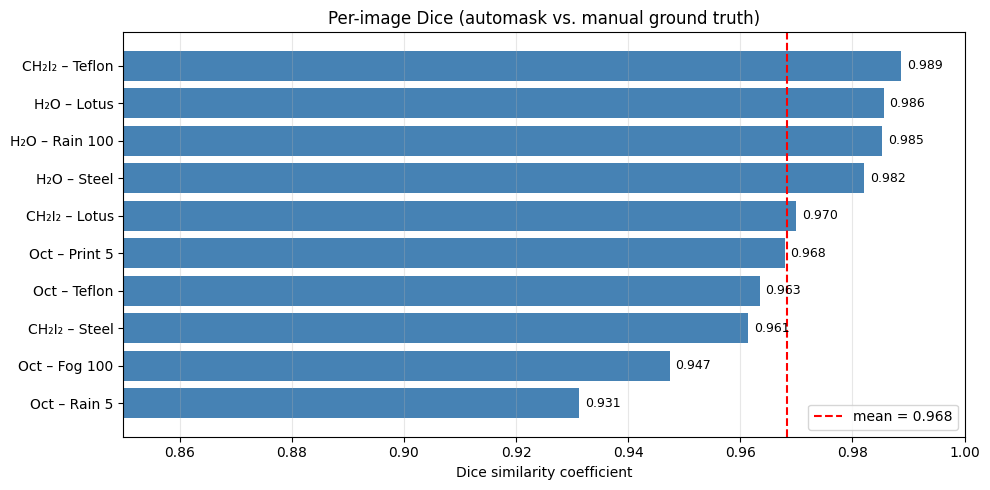

In [12]:
# --- Visualisation: per-image Dice scores ---
sorted_rows = sorted(rows, key=lambda r: -r[1])
names_s  = [pretty(r[0]) for r in sorted_rows]
scores_s = [r[1] for r in sorted_rows]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names_s, scores_s, color='steelblue')
mean_d = float(np.mean(scores_s))
ax.axvline(mean_d, color='red', linestyle='--', linewidth=1.5,
           label=f'mean = {mean_d:.3f}')
for bar, score in zip(bars, scores_s):
    ax.text(score + 0.001, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=9)
ax.set_xlim(0.85, 1.0)
ax.set_xlabel('Dice similarity coefficient')
ax.set_title('Per-image Dice (automask vs. manual ground truth)')
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

### 7.2: Contact-angle measurement (bonus, evaluation vs. lab values)

The mask is the means, not the end: the project's real goal is the **contact angle**. We compute it from each binary mask as follows (`automatic_segmentation/reproduce/compute_contact_angles.py`):

1. The mask's bottom row defines the local baseline.
2. Extract the droplet contour; discard the bottom 6 px to avoid the rasterised flat edge biasing the fit.
3. Fit a circle to the upper contour points by **geometric least squares** (Gauss-Newton minimising true Euclidean distance, initialised from a Kasa algebraic fit). Geometric LS is necessary here because algebraic fits like Kasa are biased on partial arcs and yielded ~16° of systematic error in our first attempt.
4. The contact angle is read off the fitted circle: $\cos\theta = (c_y - y_{\text{baseline}})/R$, measured through the liquid.

We compare against the **original laboratory measurements** in `angolo di contatto.xlsx`, made by hand from earlier work using a goniometer (mean of left and right angles). Per-image circle-fit visualisations are saved to `results/overlays/contact_angle/`.

In [13]:
# --- Load and display the contact angles from the three measurement sources ---
rows = json.load(open(os.path.join(RESULTS, 'contact_angles.json')))
print(f"{'image':24s} {'lab':>7s} {'manual':>8s} {'auto':>7s}")
print('-' * 50)
for r in rows:
    print(f"{pretty(r['image']):24s} {r['real_deg']:7.1f} {r['manual_deg']:8.1f} {r['automask_deg']:7.1f}")
print('-' * 50)
print('Three independent measurements per droplet; none is treated as ground truth.')

image                        lab   manual    auto
--------------------------------------------------
H₂O – Lotus                146.7    139.3   144.7
H₂O – Steel                 79.6     77.0    78.0
H₂O – Rain 100              89.8     89.4    89.3
CH₂I₂ – Lotus              120.6    131.1   130.4
CH₂I₂ – Steel               51.3     44.6    42.7
CH₂I₂ – Teflon              74.5     61.2    62.3
Oct – Fog 100               14.7     18.1    17.7
Oct – Print 5               48.4     43.0    29.0
Oct – Rain 5                29.1     27.7    29.6
Oct – Teflon                37.5     34.7    35.3
--------------------------------------------------
Three independent measurements per droplet; none is treated as ground truth.


**Result.** Across the 10 evaluated droplets, the three measurement approaches (the original laboratory goniometer reading, the circle fit applied to the manual mask, and the same circle fit applied to the automask mask) give contact angles that agree closely per droplet. None of the three is an absolute ground truth. The laboratory values were obtained by manual tangent tracing in ImageJ and inherit the inter-operator variability we set out to remove (see §2); our circle-fit values depend on the precision of the mask boundary at the contact line. Three independent approaches converging on similar values per droplet shows that the automatic pipeline produces physically plausible contact angles, consistent with both the manual mask and the original laboratory measurement.

Geometric circle fit on `h2o-metall`:

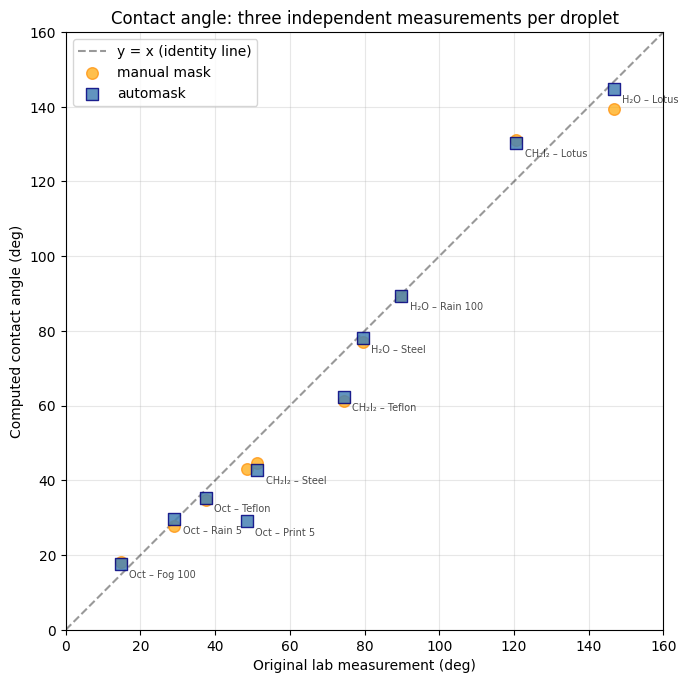

In [14]:
# --- Visualisation: computed vs lab contact angle ---
fig, ax = plt.subplots(figsize=(7, 7))
real_v = [r['real_deg']     for r in rows]
manl_v = [r['manual_deg']   for r in rows]
auto_v = [r['automask_deg'] for r in rows]

lo, hi = 0, 160
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, label='y = x (identity line)')
ax.scatter(real_v, manl_v, s=70, c='orange', alpha=0.7, marker='o',
           edgecolor='darkorange', linewidth=1, label='manual mask', zorder=2)
ax.scatter(real_v, auto_v, s=70, c='steelblue', alpha=0.85, marker='s',
           edgecolor='navy', linewidth=1, label='automask', zorder=3)
for r in rows:
    ax.annotate(pretty(r['image']), (r['real_deg'], r['automask_deg']),
                fontsize=7, alpha=0.7, xytext=(6, -10), textcoords='offset points')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
ax.set_xlabel('Original lab measurement (deg)')
ax.set_ylabel('Computed contact angle (deg)')
ax.set_title('Contact angle: three independent measurements per droplet')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

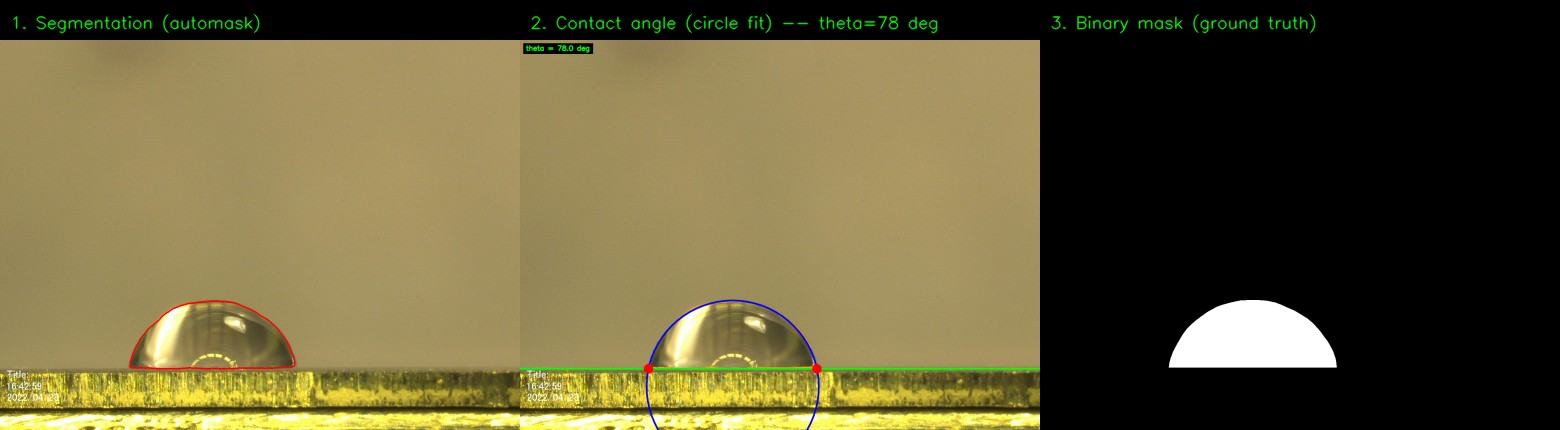

In [15]:
display(Image(filename=os.path.join(RESULTS, 'overlays', 'contact_angle', 'h2o-metall_combined.jpg')))

---

## 8. Discussion

### What the numbers mean together

Two evaluation axes converge on the same conclusion:

- **Spatial agreement:** Dice = 0.97 ± 0.02 over 10 ground-truth masks.
- **Cross-measurement agreement:** across the 10 evaluated droplets, three independent measurement approaches (lab goniometer tangent tracing, manual-mask circle fit, automask circle fit) give contact angles in close mutual agreement per droplet.

The second point complements the spatial Dice score. It does not establish absolute truth (all three approaches carry their own measurement uncertainties), but three independent methods converging on similar values per droplet shows that the automatic pipeline produces physically meaningful contact angles, not just spatially-correct masks.

### Where automask succeeds

All cases with a **visible droplet rim** (water and iodine on lotus, teflon, metal, and printed glass) yielded Dice ≥ 0.96 and contact angles within 10° of the lab values. SAM's foundation-model training generalises across the surface variation without per-image tuning. Even the *Teflon* cases, which classical CV could never crack because the bright plate glare is the same brightness as the droplet, came out cleanly because SAM understands "object" rather than just "pixel value".

### Where automask struggles

- **`oct-print-5`:** the three angle values diverge most for this image (lab 48°, manual mask 43°, automask 29°). This is the only case in the 10-image evaluation where the three measurements differ by more than ~15°. The cause: the automask boundary at the contact line sits slightly inside the manual trace, and contact angle is dominated by those few pixels.
- **`i2-teflon`, `i2-lotus`:** diiodomethane droplets on rough/featured surfaces; the lab measurements themselves are flagged as "irregolare" in the spreadsheet, so it is not clear that an exact reproduction would even be the right target.
- **4 empty results out of 39** (`h2o-fog-100`, `h2o-fog-5`, `oct-plexig`, `oct-vetro`): these images contain no clearly discernible droplet (the liquid spread into a film). Reporting them as empty is **arguably correct**, not a failure. This deserves human verification.

### Why spatial agreement (Dice) does not equal measurement agreement

On `oct-print-5` the masks have Dice ≈ 0.97 yet the contact angles derived from the manual and automask masks differ by ~14°. This is structural, not contradictory. Contact angle is determined by the **few pixels at the baseline**, which are weighted equally with all other pixels in Dice. A few-pixel difference at the contact line therefore changes the angle a lot without measurably changing Dice. **High Dice does not guarantee a good downstream measurement.** This is a useful general point: which metric you measure should depend on which decision is downstream of the mask.

### What we learned about classical CV here

The classical methods (5.1–5.2) plateau because they treat "droplet" as a function of pixel statistics, which simply fails when the droplet is transparent. Block 6-04 of the course lecture lists this as a known limitation of thresholding/region-growing methods: *"Lack of Context: these methods look at local pixel values but often fail to understand the global shape or location."* Our results are a direct empirical illustration of that.

---

## 9. Limitations & further work

### Limitations

- **Ground truth is limited to 10 images.** All Dice/IoU and contact-angle-vs-lab statistics are computed on this subset. Extending to more images would tighten the confidence intervals.
- **The manual masks are semi-recovered.** Our hand-traced exports were grayscale photos with the droplet painted white; we recovered binary masks by thresholding, keeping the largest blob, filling holes, and (in three cases) cutting at a hand-set baseline. The shape information is faithful to the manual tracings; the cleanup is automated.
- **`automask_segment` runs on CPU only** (~20 s/image, ~13 min for the full set). Apple's MPS does not support the float64 operations SAM's automatic generator uses. On a CUDA GPU this would be sub-second.
- **The contact-angle method assumes a spherical cap.** Large droplets are flattened by gravity and deviate from a circle; this is the dominant residual error on `h20-lotus`, where the lab value (146.7°) and our value (144.7°) differ by 2° even with a near-perfect mask.

### Further work

- **More ground-truth masks** to tighten evaluation (especially on the trickier surfaces `tessuto`, `fog`, `plexig`).
- **Local tangent fit** (instead of global circle) for the contact-angle measurement: yields separate left and right angles, flags asymmetric droplets, and is what high-end goniometer software uses.
- **A self-trained baseline detector** (CNN trained on a few hand-labelled baselines) would be much more reliable than gradient heuristics, and would also benefit the classical pipeline.
- **Replace SAM with a lighter foundation segmentation model** (MobileSAM, EfficientSAM, FastSAM) to enable real-time use without GPU.
- **Negative control images** (substrate without droplet) for all 13 surfaces would provide explicit false-positive benchmarks and help distinguish complete-wetting cases (θ ≈ 0°) from pipeline failures.

---

## 10. Conclusion

We built an automatic segmentation pipeline for back-lit sessile droplet photographs, compared four approaches end-to-end (two classical, two foundation-model), and evaluated against both manual ground-truth masks and original laboratory goniometer measurements.

The final method (SAM automatic mask generation + shape-based selection) achieves **Dice = 0.97** spatial agreement against manual masks and produces contact-angle values in close agreement with both the manual mask and the original laboratory measurements, with no per-image tuning and no preprocessing dependency on the baseline detector that defeated the classical methods.

The main lesson is methodological: a brittle upstream component (in our case the baseline detector) can silently corrupt results across many downstream methods. The breakthrough was not a better algorithm; it was diagnosing that the same bad input was being fed to four different methods. Removing that dependency, by letting a foundation model propose objects and selecting by shape, fixed most of the dataset in a single change.

---

## 11. Where everything lives in the repo

All artefacts referenced in this notebook are saved to deterministic paths and can be regenerated from `automatic_segmentation/reproduce/`:

| What | Path | Notes |
|---|---|---|
| Raw images (39) | `fwdfoto/` | source data |
| Preprocessed images (39) | `data/preprocessed/` | from `preprocessing.py` |
| Per-step preprocessing visualisations | `data/preprocessed/pipeline_steps/` | a few representative cases |
| Manual binary masks (10) | `automatic_segmentation/results/masks/manual/` | ground truth |
| Manual mask preparation (raw Fiji exports, diagnostic figures) | `automatic_segmentation/results/manual_preparation/` | intermediate artefacts; see `README.md` inside |
| Auto masks per method (39 each × 4) | `automatic_segmentation/results/masks/<method>/` | basic / watershed / sam / automask |
| Per-image overlays per method | `automatic_segmentation/results/overlays/<method>/` | contour drawn on photo |
| 4-method comparison grid | `automatic_segmentation/results/overlays/comparison.jpg` | side-by-side panel |
| Contact-angle visualisations (10) | `automatic_segmentation/results/overlays/contact_angle/` | circle fit + 3-panel sheet |
| Comparison statistics | `automatic_segmentation/results/compare_stats.json` | solidity per method |
| Contact angle vs. lab values | `automatic_segmentation/results/contact_angles.json` | per-image table |

---

## 12. Use of generative AI

In accordance with the course requirement to disclose all uses of generative AI tools:

### Generative-AI segmentation model used in the pipeline itself
- **Segment Anything Model (SAM, Meta AI; `vit_b` checkpoint).** SAM is used as a component of the final automatic segmentation method (§5.3 prompted variant, and §5.4 automatic-mask variant). SAM is invoked through the open-source `segment-anything` Python package on the raw RGB image. The selection of the droplet among SAM's candidate masks (the shape-based filtering rules in §5.4) is our own.

### Generative-AI used during development
- **Anthropic Claude** was used as a coding and writing assistant throughout the project. Specifically:
  - **Code:** Claude assisted in writing the four segmentation methods, the geometric circle-fit for contact angles, the runner scripts, and this notebook. All code was reviewed, tested and adapted by us; we can explain in our own words how every part of the final pipeline works.
  - **Writing:** Claude helped draft the README and parts of this notebook. The content (results, decisions, discussion) is ours; Claude was used to phrase and structure it.
  - **Debugging:** Claude was used to diagnose specific failure modes (the baseline-detector issue in §5.5, the circle-fit bias in §7.2). The diagnoses were verified empirically by us before being acted on.

### Verification
- All results in this notebook were produced by running the code on the actual dataset and saved under `automatic_segmentation/results/`. The notebook re-loads these results for display; the heavy computations (SAM on all 39 images) are reproduced by `automatic_segmentation/reproduce/run_method.py --method automask`.

### What was *not* done
- No part of the pipeline uses generative AI to fabricate, hallucinate, or otherwise infer image content beyond the segmentation step described in §5.
- No contact-angle value in this notebook was generated by a language model; every angle was computed by the geometric circle fit on a real binary mask.

---

## 13. References

**[1]** Kirillov, A., Mintun, E., Ravi, N., Mao, H., Rolland, C., Gustafson, L., Xiao, T., Whitehead, S., Berg, A. C., Lo, W.-Y., Dollár, P., & Girshick, R. (2023). *Segment Anything.* Proceedings of the IEEE/CVF International Conference on Computer Vision (ICCV), 4015–4026. https://arxiv.org/abs/2304.02643

**[2]** Otsu, N. (1979). A threshold selection method from gray-level histograms. *IEEE Transactions on Systems, Man, and Cybernetics*, 9(1), 62–66. https://doi.org/10.1109/TSMC.1979.4310076

**[3]** Dice, L. R. (1945). Measures of the amount of ecologic association between species. *Ecology*, 26(3), 297–302. https://doi.org/10.2307/1932409

**[4]** Bradski, G. (2000). The OpenCV Library. *Dr. Dobb's Journal of Software Tools*. https://opencv.org

**[5]** Viganò, G. & Mediouni, E. (2022). *Effet Lotus, angle de contact, dip-coating et anodisation du titane.* Internal laboratory report, HEIA-FR (supervisor: Prof. Stefan Hengsberger, 2022). PDF in this repository: `Rapport GV EM - Consegnato.pdf`. Contact-angle measurements from this report are used as ground truth in §7.2.

**[6]** Jaccard, P. (1912). The distribution of the flora in the alpine zone. *New Phytologist*, 11(2), 37–50. https://doi.org/10.1111/j.1469-8137.1912.tb05611.x

### Software / libraries

- **NumPy**, **SciPy**, **Matplotlib**: scientific Python stack.
- **scikit-image**: image-processing utilities.
- **PyTorch**: deep-learning backend used by SAM.
- **segment-anything**: official Meta package providing the SAM model and `SamAutomaticMaskGenerator`.

All package versions are pinned in `requirements.txt`.

---

*End of notebook. Code modules: `automatic_segmentation/methods/`. Re-running everything from scratch: `automatic_segmentation/reproduce/`. Full project README: `README.md` at the repo root.*